# The Extended Kalman Filter
# 扩展卡尔曼滤波器


In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

请在继续之前安装 SymPy。有关说明，请参阅第 0 章。


We have developed the theory for the linear Kalman filter. Then, in the last two chapters we broached the topic of using Kalman filters for nonlinear problems. In this chapter we will learn the Extended Kalman filter (EKF). The EKF handles nonlinearity by linearizing the system at the point of the current estimate, and then the linear Kalman filter is used to filter this linearized system. It was one of the very first techniques used for nonlinear problems, and it remains the most common technique.

前面我们已经建立了线性卡尔曼滤波器的理论，并在最近两章探讨了用卡尔曼滤波器处理非线性问题。本章要学习扩展卡尔曼滤波器 (EKF)。EKF 在当前估计点处对系统做线性化，再用线性卡尔曼滤波器去滤波这个线性化后的系统，由此处理非线性。它是最早用于非线性问题的技术之一，至今仍是最常用的技术。

The EKF provides significant mathematical challenges to the designer of the filter; this is the most challenging chapter of the book. I do everything I can to avoid the EKF in favor of other techniques that have been developed to filter nonlinear problems. However, the topic is unavoidable; all classic papers and a majority of current papers in the field use the EKF. Even if you do not use the EKF in your own work you will need to be familiar with the topic to be able to read the literature.

EKF 给滤波器设计者带来很大的数学挑战，本章也是全书最难的一章。我总是尽量回避 EKF，改用其他已有技术来处理非线性滤波。然而这个话题绕不开：该领域的经典论文、乃至当前大多数论文，用的都是 EKF。即便你在自己的工作中不用 EKF，也得熟悉它才能读懂文献。


## Linearizing the Kalman Filter
## 对卡尔曼滤波器线性化

The Kalman filter uses linear equations, so it does not work with nonlinear problems. Problems can be nonlinear in two ways. First, the process model might be nonlinear. An object falling through the atmosphere encounters drag which reduces its acceleration. The drag coefficient varies based on the velocity the object. The resulting behavior is nonlinear - it cannot be modeled with linear equations. Second, the measurements could be nonlinear. For example, a radar gives a range and bearing to a target. We use trigonometry, which is nonlinear, to compute the position of the target.

卡尔曼滤波器建立在方程线性的前提上，因此不适用于非线性问题。非线性可能来自两方面。其一是过程模型：穿过大气层的物体会受到阻力，从而减小其加速度，而阻力系数又随物体速度变化，由此产生的行为是非线性的，无法用线性方程描述。其二是测量：例如雷达给出目标的距离和方位，我们要用非线性三角函数才能算出目标位置。

For the linear filter we have these equations for the process and measurement models:

对于线性滤波器，我们有这些过程和测量模型的方程:

$$\begin{aligned}\dot{\mathbf x} &= \mathbf{Ax} + w_x\\
\mathbf z &= \mathbf{Hx} + w_z
\end{aligned}$$

Where $\mathbf A$ is the systems dynamic matrix. Using the state space methods covered in the **Kalman Filter Math** chapter these equations can be transformed into

其中 $\mathbf A$ 是系统动力学矩阵。利用**卡尔曼滤波器数学**一章介绍的状态空间方法，这些方程可以改写为

$$\begin{aligned}\bar{\mathbf x} &= \mathbf{Fx} \\
\mathbf z &= \mathbf{Hx}
\end{aligned}$$

where $\mathbf F$ is the *fundamental matrix*. The noise $w_x$ and $w_z$ terms are incorporated into the matrices $\mathbf R$ and $\mathbf Q$. This form of the equations allow us to compute the state at step $k$ given a measurement at step $k$ and the state estimate at step $k-1$. In earlier chapters I built your intuition and minimized the math by using problems describable with Newton's equations. We know how to design $\mathbf F$ based on high school physics.

其中 $\mathbf F$ 是*基本矩阵*。噪声项 $w_x$ 和 $w_z$ 被并入矩阵 $\mathbf R$ 和 $\mathbf Q$。这种形式的方程让我们可以由步骤 $k$ 的测量值和步骤 $k-1$ 的状态估计算出步骤 $k$ 的状态。前面几章里，我用牛顿方程描述的例题来建立直觉、减少数学推导，那种情况下我们靠高中物理就能设计出 $\mathbf F$。

For the nonlinear model the linear expression $\mathbf{Fx} + \mathbf{Bu}$ is replaced by a nonlinear function $f(\mathbf x, \mathbf u)$, and the linear expression $\mathbf{Hx}$ is replaced by a nonlinear function $h(\mathbf x)$:

对于非线性模型，线性表达式 $\mathbf{Fx} + \mathbf{Bu}$ 被非线性函数 $f(\mathbf x, \mathbf u)$ 代替，线性表达式 $\mathbf{Hx}$ 由非线性函数 $h(\mathbf x)$ 代替：

$$\begin{aligned}\dot{\mathbf x} &= f(\mathbf x, \mathbf u) + w_x\\
\mathbf z &= h(\mathbf x) + w_z
\end{aligned}$$

你也许会想：能不能找到一套新的卡尔曼滤波方程来直接求解它们？但如果还记得**非线性滤波**一章中的图，你就知道原因：高斯通过非线性函数后会变成非高斯分布。所以这条路走不通。

The EKF does not alter the Kalman filter's linear equations. Instead, it *linearizes* the nonlinear equations at the point of the current estimate, and uses this linearization in the linear Kalman filter.

EKF 并不改动卡尔曼滤波器的线性方程，而是在当前估计点处把非线性方程*线性化*，再把这个线性化结果放进线性卡尔曼滤波器里使用。

*Linearize* means what it sounds like. We find a line that most closely matches the curve at a defined point. The graph below linearizes the parabola $f(x)=x^2-2x$ at $x=1.5$.

*线性化*的意思正如其名：在给定点处找一条与曲线最贴近的直线。下图把抛物线 $f(x)=x^2-2x$ 在 $x=1.5$ 处线性化。


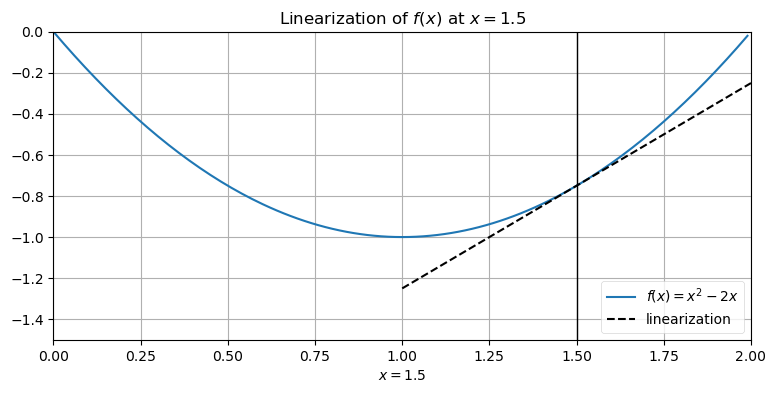

In [3]:
import kf_book.ekf_internal as ekf_internal
ekf_internal.show_linearization()

If the curve above is the process model, then the dotted lines shows the linearization of that curve for the estimate $x=1.5$.

如果上面的曲线是过程模型，那么虚线显示了该曲线的线性化估计值 $x=1.5$。

We linearize systems by taking the derivative, which finds the slope of a curve:

我们通过求导数来线性化系统，求出曲线的斜率：

$$\begin{aligned}
f(x) &= x^2 -2x \\
\frac{df}{dx} &= 2x - 2
\end{aligned}$$

然后在 $x$ 处评估它：

$$\begin{aligned}m &= f'(x=1.5) \\&= 2(1.5) - 2 \\&= 1\end{aligned}$$

Linearizing systems of differential equations is similar. We linearize $f(\mathbf x, \mathbf u)$, and $h(\mathbf x)$ by taking the partial derivatives of each to evaluate $\mathbf F$ and $\mathbf H$ at the point $\mathbf x_t$ and $\mathbf u_t$. We call the partial derivative of a matrix the [*Jacobian*](https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant). This gives us the the discrete state transition matrix and measurement model matrix:

线性化微分方程组也是类似的做法：我们在点 $\mathbf x_t$ 和 $\mathbf u_t$ 处对 $f(\mathbf x, \mathbf u)$ 和 $h(\mathbf x)$ 求偏导数。矩阵的偏导数称为[*雅可比矩阵*](https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant)。由此得到离散的状态转移矩阵和测量模型矩阵：

$$
\begin{aligned}
\mathbf F 
&= {\frac{\partial{f(\mathbf x_t, \mathbf u_t)}}{\partial{\mathbf x}}}\biggr|_{{\mathbf x_t},{\mathbf u_t}} \\
\mathbf H &= \frac{\partial{h(\bar{\mathbf x}_t)}}{\partial{\bar{\mathbf x}}}\biggr|_{\bar{\mathbf x}_t} 
\end{aligned}
$$

This leads to the following equations for the EKF. I put boxes around the differences from the linear filter:

这导致 EKF 的以下等式。我在与线性滤波器的差异周围放了框：

$$\begin{array}{l|l}
\text{linear Kalman filter} & \text{EKF} \\
\hline 
& \boxed{\mathbf F = {\frac{\partial{f(\mathbf x_t, \mathbf u_t)}}{\partial{\mathbf x}}}\biggr|_{{\mathbf x_t},{\mathbf u_t}}} \\
\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu} & \boxed{\mathbf{\bar x} = f(\mathbf x, \mathbf u)}  \\
\mathbf{\bar P} = \mathbf{FPF}^\mathsf{T}+\mathbf Q  & \mathbf{\bar P} = \mathbf{FPF}^\mathsf{T}+\mathbf Q \\
\hline 
& \boxed{\mathbf H = \frac{\partial{h(\bar{\mathbf x}_t)}}{\partial{\bar{\mathbf x}}}\biggr|_{\bar{\mathbf x}_t}} \\
\textbf{y} = \mathbf z - \mathbf{H \bar{x}} & \textbf{y} = \mathbf z - \boxed{h(\bar{x})}\\
\mathbf{K} = \mathbf{\bar{P}H}^\mathsf{T} (\mathbf{H\bar{P}H}^\mathsf{T} + \mathbf R)^{-1} & \mathbf{K} = \mathbf{\bar{P}H}^\mathsf{T} (\mathbf{H\bar{P}H}^\mathsf{T} + \mathbf R)^{-1} \\
\mathbf x=\mathbf{\bar{x}} +\mathbf{K\textbf{y}} & \mathbf x=\mathbf{\bar{x}} +\mathbf{K\textbf{y}} \\
\mathbf P= (\mathbf{I}-\mathbf{KH})\mathbf{\bar{P}} & \mathbf P= (\mathbf{I}-\mathbf{KH})\mathbf{\bar{P}}
\end{array}$$

We don't normally use $\mathbf{Fx}$ to propagate the state for the EKF as the linearization causes inaccuracies. It is typical to compute $\bar{\mathbf x}$ using a suitable numerical integration technique such as Euler or Runge Kutta. Thus I wrote $\mathbf{\bar x} = f(\mathbf x, \mathbf u)$. For the same reasons we don't use $\mathbf{H\bar{x}}$ in the computation for the residual, opting for the more accurate $h(\bar{\mathbf x})$.

我们通常不使用 $\mathbf{Fx}$ 来传播 EKF 的状态，因为线性化会导致不准确。通常使用合适的数值积分技术（例如 Euler 或 Runge Kutta）计算 $\bar{\mathbf x}$。因此我写了 $\mathbf{\bar x} = f(\mathbf x, \mathbf u)$。出于同样的原因，我们在残差计算中不使用 $\mathbf{H\bar{x}}$，而是选择更准确的 $h(\bar{\mathbf x})$。

I think the easiest way to understand the EKF is to start off with an example. Later you may want to come back and reread this section.

我认为理解 EKF 的最简单方法是从一个例子开始。稍后你可能想回来重新阅读本节。


## Example: Tracking a Airplane
## 示例：跟踪一架飞机

This example tracks an airplane using ground based radar. We implemented a UKF for this problem in the last chapter. Now we will implement an EKF for the same problem so we can compare both the filter performance and the level of effort required to implement the filter.

本示例使用地基雷达跟踪飞机。我们在上一章中为这个问题实现了一个 UKF。现在我们将针对同一问题实施 EKF，以便我们可以比较滤波器性能和实施滤波器所需的工作水平。

Radars work by emitting a beam of radio waves and scanning for a return bounce. Anything in the beam's path will reflects some of the signal back to the radar. By timing how long it takes for the reflected signal to get back to the radar the system can compute the *slant distance* - the straight line distance from the radar installation to the object.

雷达通过发射一束无线电波并扫描返回反弹来工作。光束路径中的任何东西都会将一些信号反射回雷达。通过对反射信号返回雷达所需的时间进行计时，系统可以计算*斜距* - 从雷达装置到物体的直线距离。

The relationship between the radar's slant range distance $r$ and elevation angle $\epsilon$ with the horizontal position $x$ and altitude $y$ of the aircraft is illustrated in the figure below:

雷达斜距$r$和仰角$\epsilon$与飞机水平位置$x$和高度$y$的关系如下图所示：


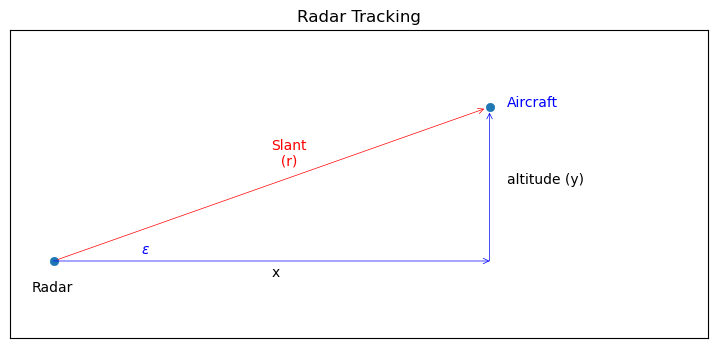

In [4]:
ekf_internal.show_radar_chart()

This gives us the equalities:

这给了我们等式：

$$\begin{aligned}
\epsilon &= \tan^{-1} \frac y x\\
r^2 &= x^2 + y^2
\end{aligned}$$


### Design the State Variables
### 设计状态变量

We want to track the position of an aircraft assuming a constant velocity and altitude, and measurements of the slant distance to the aircraft. That means we need 3 state variables - horizontal distance, horizontal velocity, and altitude:

我们想在假设速度和高度恒定的情况下跟踪飞机的位置，并测量到飞机的斜距。这意味着我们需要 3 个状态变量，水平距离、水平速度和高度：

$$\mathbf x = \begin{bmatrix}\mathtt{distance} \\\mathtt{velocity}\\ \mathtt{altitude}\end{bmatrix}=    \begin{bmatrix}x \\ \dot x\\ y\end{bmatrix}$$


### Design the Process Model
### 设计过程模型

We assume a Newtonian, kinematic system for the aircraft. We've used this model in previous chapters, so by inspection you may recognize that we want

我们假设飞机采用牛顿运动学系统。我们在前面的章节中使用过这个模型，所以通过检查你可能会认识到我们想要

$$\mathbf F = \left[\begin{array}{cc|c} 1 & \Delta t & 0\\
0 & 1 & 0 \\ \hline
0 & 0 & 1\end{array}\right]$$

I've partioned the matrix into blocks to show the upper left block is a constant velocity model for $x$, and the lower right block is a constant position model for $y$.

我已将矩阵分成块以显示左上块是 $x$ 的恒定速度模型，右下块是 $y$ 的恒定位置模型。

However, let's practice finding these matrices. We model systems with a set of differential equations. We need an equation in the form

但是，让我们练习查找这些矩阵。我们用一组微分方程对系统进行建模。我们需要一个形式为

$$\dot{\mathbf x} = \mathbf{Ax} + \mathbf{w}$$

where $\mathbf{w}$ is the system noise.

其中 $\mathbf{w}$ 是系统噪声。

The variables $x$ and $y$ are independent so we can compute them separately. The differential equations for motion in one dimension are:

变量 $x$ 和 $y$ 是独立的，因此我们可以分别计算它们。一维运动的微分方程为：

$$\begin{aligned}v &= \dot x \\
a &= \ddot{x} = 0\end{aligned}$$

Now we put the differential equations into state-space form. If this was a second or greater order differential system we would have to first reduce them to an equivalent set of first degree equations. The equations are first order, so we put them in state space matrix form as

现在我们把微分方程变成状态空间形式。如果这是一个二阶或更高阶微分系统，我们必须首先将它们简化为一组等效的一阶方程。方程是一阶的，所以我们把它们放在状态空间矩阵的形式中

$$\begin{aligned}\begin{bmatrix}\dot x \\ \ddot{x}\end{bmatrix} &= \begin{bmatrix}0&1\\0&0\end{bmatrix} \begin{bmatrix}x \\ 
\dot x\end{bmatrix} \\ \dot{\mathbf x} &= \mathbf{Ax}\end{aligned}$$

where $\mathbf A=\begin{bmatrix}0&1\\0&0\end{bmatrix}$.

其中 $\mathbf A=\begin{bmatrix}0&1\\0&0\end{bmatrix}$。

Recall that $\mathbf A$ is the *system dynamics matrix*. It describes a set of linear differential equations. From it we must compute the state transition matrix $\mathbf F$. $\mathbf F$ describes a discrete set of linear equations which compute $\mathbf x$ for a discrete time step $\Delta t$.

回想一下 $\mathbf A$ 是*系统动力学矩阵*。它描述了一组线性微分方程。我们必须从中计算状态转移矩阵 $\mathbf F$。$\mathbf F$ 描述了一组离散的线性方程，这些方程为离散时间步 $\Delta t$ 计算 $\mathbf x$。

A common way to compute $\mathbf F$ is to use the power series expansion of the matrix exponential:

计算 $\mathbf F$ 的常用方法是使用矩阵指数的幂级数展开：

$$\mathbf F(\Delta t) = e^{\mathbf A\Delta t} = \mathbf{I} + \mathbf A\Delta t  + \frac{(\mathbf A\Delta t)^2}{2!} + \frac{(\mathbf A \Delta t)^3}{3!} + ... $$

$\mathbf A^2 = \begin{bmatrix}0&0\\0&0\end{bmatrix}$, so all higher powers of $\mathbf A$ are also $\mathbf{0}$. Thus the power series expansion is:

$\mathbf A^2 = \begin{bmatrix}0&0\\0&0\end{bmatrix}$，所以$\mathbf A$ 的所有高次幂也是$\mathbf{0}$。因此幂级数展开是：

$$
\begin{aligned}
\mathbf F &=\mathbf{I} + \mathbf At + \mathbf{0} \\
&= \begin{bmatrix}1&0\\0&1\end{bmatrix} + \begin{bmatrix}0&1\\0&0\end{bmatrix}\Delta t\\
\mathbf F &= \begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}
\end{aligned}$$

This is the same result used by the kinematic equations! This exercise was unnecessary other than to illustrate finding the state transition matrix from linear differential equations. We will conclude the chapter with an example that will require the use of this technique.

这与运动学方程使用的结果相同！除了说明从线性微分方程找到状态转移矩阵之外，这个练习是不必要的。我们将用一个需要使用这种技术的例子来结束本章。


### Design the Measurement Model
### 设计测量模型

The measurement function takes the state estimate of the prior $\bar{\mathbf x}$ and turn it into a measurement of the slant range distance. We use the Pythagorean theorem to derive:

测量函数采用先验 $\bar{\mathbf x}$ 的状态估计并将其转换为斜距距离的测量值。我们使用勾股定理推导出：

$$h(\bar{\mathbf x}) = \sqrt{x^2 + y^2}$$

The relationship between the slant distance and the position on the ground is nonlinear due to the square root. We linearize it by evaluating its partial derivative at $\mathbf x_t$:

由于平方根，斜距与地面位置之间的关系是非线性的。我们通过评估其在 $\mathbf x_t$ 处的偏导数对其进行线性化：

$$
\mathbf H = \frac{\partial{h(\bar{\mathbf x})}}{\partial{\bar{\mathbf x}}}\biggr|_{\bar{\mathbf x}_t}
$$

The partial derivative of a matrix is called a Jacobian, and takes the form

矩阵的偏导数称为雅可比矩阵，其形式为

$$\frac{\partial \mathbf H}{\partial \bar{\mathbf x}} = 
\begin{bmatrix}
\frac{\partial h_1}{\partial x_1} & \frac{\partial h_1}{\partial x_2} &\dots \\
\frac{\partial h_2}{\partial x_1} & \frac{\partial h_2}{\partial x_2} &\dots \\
\vdots & \vdots
\end{bmatrix}
$$

In other words, each element in the matrix is the partial derivative of the function $h$ with respect to the $x$ variables. For our problem we have

换句话说，矩阵中的每个元素都是函数 $h$ 相对于 $x$ 变量的偏导数。对于我们的问题，我们有

$$\mathbf H = \begin{bmatrix}{\partial h}/{\partial x} & {\partial h}/{\partial \dot{x}} & {\partial h}/{\partial y}\end{bmatrix}$$

Solving each in turn:

逐一求解：

$$\begin{aligned}
\frac{\partial h}{\partial x} &= \frac{\partial}{\partial x} \sqrt{x^2 + y^2} \\
&= \frac{x}{\sqrt{x^2 + y^2}}
\end{aligned}$$

and

而

$$\begin{aligned}
\frac{\partial h}{\partial \dot{x}} &=
\frac{\partial}{\partial \dot{x}} \sqrt{x^2 + y^2} \\ 
&= 0
\end{aligned}$$

and

而

$$\begin{aligned}
\frac{\partial h}{\partial y} &= \frac{\partial}{\partial y} \sqrt{x^2 + y^2} \\ 
&= \frac{y}{\sqrt{x^2 + y^2}}
\end{aligned}$$

giving us

于是得到

$$\mathbf H = 
\begin{bmatrix}
\frac{x}{\sqrt{x^2 + y^2}} & 
0 &
& \frac{y}{\sqrt{x^2 + y^2}}
\end{bmatrix}
$$

This may seem daunting, so step back and recognize that all of this math is doing something very simple. We have an equation for the slant range to the airplane which is nonlinear. The Kalman filter only works with linear equations, so we need to find a linear equation that approximates $\mathbf H$. As we discussed above, finding the slope of a nonlinear equation at a given point is a good approximation. For the Kalman filter, the 'given point' is the state variable $\mathbf x$ so we need to take the derivative of the slant range with respect to $\mathbf x$. For the linear Kalman filter $\mathbf H$ was a constant that we computed prior to running the filter. For the EKF $\mathbf H$ is updated at each step as the evaluation point $\bar{\mathbf x}$ changes at each epoch.

这可能看起来令人生畏，所以退后一步并认识到所有这些数学都是在做一些非常简单的事情。我们有一个非线性的飞机斜距方程。卡尔曼滤波器只适用于线性方程，因此我们需要找到一个近似于 $\mathbf H$ 的线性方程。正如我们上面讨论的，在给定点找到非线性方程的斜率是一个很好的近似。对于卡尔曼滤波器，“给定点”是状态变量 $\mathbf x$，因此我们需要取相对于 $\mathbf x$ 的斜距的导数。对于线性卡尔曼滤波器，$\mathbf H$ 是我们在运行滤波器之前计算的常数。对于 EKF，$\mathbf H$ 在每一步都会随着评估点 $\bar{\mathbf x}$ 在每个时期的变化而更新。

To make this more concrete, let's now write a Python function that computes the Jacobian of $h$ for this problem.

为了更具体地说明这一点，现在让我们编写一个 Python 函数来计算这个问题的 $h$ 的雅可比行列式。


In [5]:
from math import sqrt
def HJacobian_at(x):
    """ compute Jacobian of H matrix at x """

    horiz_dist = x[0]
    altitude   = x[2]
    denom = sqrt(horiz_dist**2 + altitude**2)
    return array ([[horiz_dist/denom, 0., altitude/denom]])

Finally, let's provide the code for $h(\bar{\mathbf x})$:

最后，让我们提供 $h(\bar{\mathbf x})$ 的代码：


In [6]:
def hx(x):
    """ compute measurement for slant range that
    would correspond to state x.
    """
    
    return (x[0]**2 + x[2]**2) ** 0.5

Now let's write a simulation for our radar.

现在让我们为我们的雷达编写一个模拟。


In [7]:
from numpy.random import randn
import math

class RadarSim:
    """ Simulates the radar signal returns from an object
    flying at a constant altityude and velocity in 1D. 
    """
    
    def __init__(self, dt, pos, vel, alt):
        self.pos = pos
        self.vel = vel
        self.alt = alt
        self.dt = dt
        
    def get_range(self):
        """ Returns slant range to the object. Call once 
        for each new measurement at dt time from last call.
        """
        
        # add some process noise to the system
        self.vel = self.vel  + .1*randn()
        self.alt = self.alt + .1*randn()
        self.pos = self.pos + self.vel*self.dt
    
        # add measurement noise
        err = self.pos * 0.05*randn()
        slant_dist = math.sqrt(self.pos**2 + self.alt**2)
        
        return slant_dist + err

### Design Process and Measurement Noise
### 设计过程噪声与测量噪声

The radar measures the range to a target. We will use $\sigma_{range}= 5$ meters for the noise. This gives us

雷达测量到目标的距离。我们将使用 $\sigma_{range}= 5$ 米作为噪声。这给了我们

$$\mathbf R = \begin{bmatrix}\sigma_{range}^2\end{bmatrix} = \begin{bmatrix}25\end{bmatrix}$$

The design of $\mathbf Q$ requires some discussion. The state $\mathbf x= \begin{bmatrix}x & \dot x & y\end{bmatrix}^\mathtt{T}$. The first two elements are position (down range distance) and velocity, so we can use `Q_discrete_white_noise` noise to compute the values for the upper left hand side of $\mathbf Q$. The third element of $\mathbf x$ is altitude, which we are assuming is independent of the down range distance. That leads us to a block design of $\mathbf Q$ of:

$\mathbf Q$ 的设计需要一些讨论。状态 $\mathbf x= \begin{bmatrix}x & \dot x & y\end{bmatrix}^\mathtt{T}$。前两个元素是位置（向下距离）和速度，因此我们可以使用“Q_discrete_white_noise”噪声来计算 $\mathbf Q$ 左上角的值。$\mathbf x$ 的第三个元素是高度，我们假设它与下行距离无关。这导致我们对 $\mathbf Q$ 的块设计：

$$\mathbf Q = \begin{bmatrix}\mathbf Q_\mathtt{x} & 0 \\ 0 & \mathbf Q_\mathtt{y}\end{bmatrix}$$


### Implementation
### 实现

`FilterPy` provides the class `ExtendedKalmanFilter`. It works similarly to the `KalmanFilter` class we have been using, except that it allows you to provide a function that computes the Jacobian of $\mathbf H$ and the function $h(\mathbf x)$.

`FilterPy` 提供了 `ExtendedKalmanFilter` 类。它的用法与我们一直使用的 `KalmanFilter` 类相似，区别在于它允许你提供一个函数来计算 $\mathbf H$ 的雅可比矩阵，以及一个函数 $h(\mathbf x)$。

We start by importing the filter and creating it. The dimension of `x` is 3 and `z` has dimension 1.

先把滤波器导入并创建出来。`x` 的维度是 3，`z` 的维度是 1。

```python
from filterpy.kalman import ExtendedKalmanFilter

rk = ExtendedKalmanFilter(dim_x=3, dim_z=1)
```

We create the radar simulator:

创建雷达模拟器：

```python
radar = RadarSim(dt, pos=0., vel=100., alt=1000.)
```

We will initialize the filter near the airplane's actual position:

在飞机的实际位置附近初始化滤波器：

```python
rk.x = array([radar.pos, radar.vel-10, radar.alt+100])
```

We assign the system matrix using the first term of the Taylor series expansion we computed above:

用前面算出的泰勒级数展开式的第一项来赋值系统矩阵：

```python
dt = 0.05
rk.F = eye(3) + array([[0, 1, 0],
                       [0, 0, 0],
                       [0, 0, 0]])*dt
```

After assigning reasonable values to $\mathbf R$, $\mathbf Q$, and $\mathbf P$ we can run the filter with a simple loop. We pass the functions for computing the Jacobian of $\mathbf H$ and $h(x)$ into the `update` method.

为 $\mathbf R$、$\mathbf Q$ 和 $\mathbf P$ 赋上合理的值之后，就可以用一个简单的循环来运行滤波器了。我们把计算 $\mathbf H$ 的雅可比矩阵的函数和 $h(x)$ 传给 `update` 方法。

```python
for i in range(int(20/dt)):
    z = radar.get_range()
    rk.update(array([z]), HJacobian_at, hx)
    rk.predict()
```

Adding some boilerplate code to save and plot the results we get:

再加上一些样板代码来保存并绘制结果，就得到：


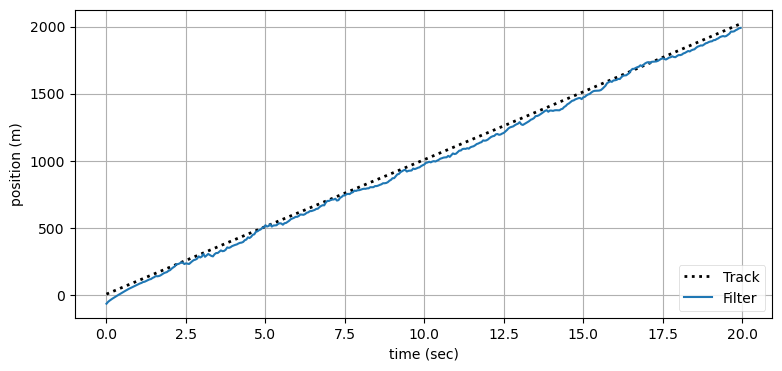

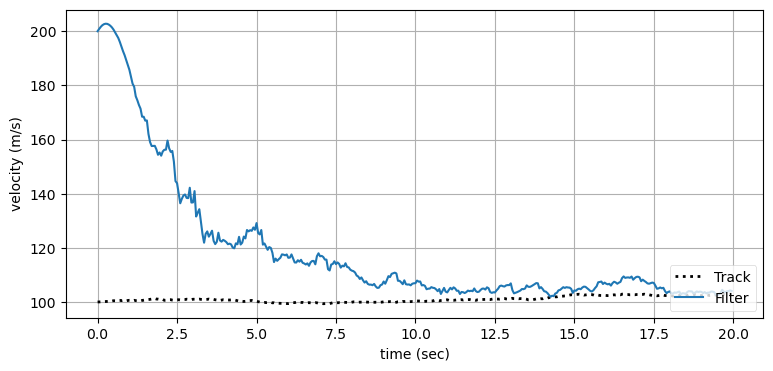

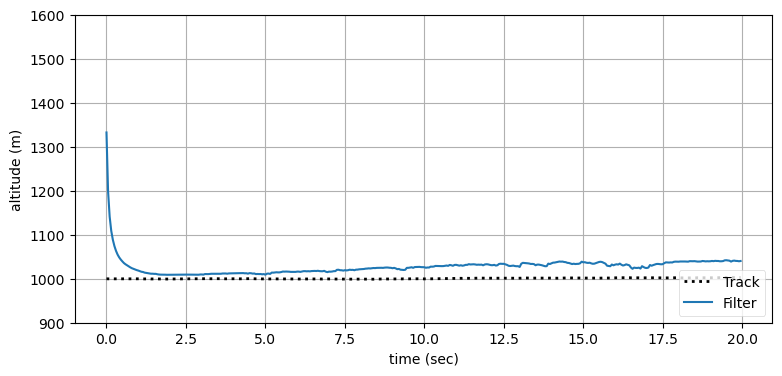

In [8]:
from filterpy.common import Q_discrete_white_noise
from filterpy.kalman import ExtendedKalmanFilter
from numpy import eye, array, asarray
import numpy as np

dt = 0.05
rk = ExtendedKalmanFilter(dim_x=3, dim_z=1)
radar = RadarSim(dt, pos=0., vel=100., alt=1000.)

# make an imperfect starting guess
rk.x = array([radar.pos-100, radar.vel+100, radar.alt+1000])

rk.F = eye(3) + array([[0, 1, 0],
                       [0, 0, 0],
                       [0, 0, 0]]) * dt

range_std = 5. # meters
rk.R = np.diag([range_std**2])
rk.Q[0:2, 0:2] = Q_discrete_white_noise(2, dt=dt, var=0.1)
rk.Q[2,2] = 0.1
rk.P *= 50

xs, track = [], []
for i in range(int(20/dt)):
    z = radar.get_range()
    track.append((radar.pos, radar.vel, radar.alt))
    
    rk.update(array([z]), HJacobian_at, hx)
    xs.append(rk.x)
    rk.predict()

xs = asarray(xs)
track = asarray(track)
time = np.arange(0, len(xs)*dt, dt)
ekf_internal.plot_radar(xs, track, time)

## Using SymPy to compute Jacobians
## 使用 SymPy 计算雅可比矩阵

Depending on your experience with derivatives you may have found the computation of the Jacobian difficult. Even if you found it easy, a slightly more difficult problem easily leads to very difficult computations.

如果你对求导不太熟练，计算雅可比矩阵可能会觉得吃力；即便你觉得轻松，问题稍微复杂一点，计算也会立刻变得非常困难。

As explained in Appendix A, we can use the SymPy package to compute the Jacobian for us.

如附录 A 中所述，我们可以使用 SymPy 包为我们计算雅可比矩阵。


In [9]:
import sympy
from IPython.display import display
sympy.init_printing(use_latex='mathjax')

x, x_vel, y = sympy.symbols('x, x_vel y')

H = sympy.Matrix([sympy.sqrt(x**2 + y**2)])

state = sympy.Matrix([x, x_vel, y])
J = H.jacobian(state)

display(state)
display(J)

⎡ x  ⎤
⎢    ⎥
⎢xᵥₑₗ⎥
⎢    ⎥
⎣ y  ⎦

⎡     x                y      ⎤
⎢────────────  0  ────────────⎥
⎢   _________        _________⎥
⎢  ╱  2    2        ╱  2    2 ⎥
⎣╲╱  x  + y       ╲╱  x  + y  ⎦

This result is the same as the result we computed above, and with much less effort on our part!

这个结果与上面手算的结果相同，而我们省力得多！


## Robot Localization
## 机器人定位

It's time to try a real problem. I warn you that this section is difficult. However, most books choose simple, textbook problems with simple answers, and you are left wondering how to solve a real world problem.

接下来该动真格了。提醒你一下，这部分很难。多数教材喜欢挑答案简单的教科书式例题，结果读者仍不知道该如何解决现实中的问题。

We will consider the problem of robot localization. We already implemented this in the **Unscented Kalman Filter** chapter, and I recommend you read it now if you haven't already. In this scenario we have a robot that is moving through a landscape using a sensor to detect landmarks. This could be a self driving car using computer vision to identify trees, buildings, and other landmarks. It might be one of those small robots that vacuum your house, or a robot in a warehouse.

我们将考虑机器人定位问题。我们已经在 **Unscented Kalman Filter** 章节中实现了这一点，如果你还没有阅读，我建议你现在阅读。在这个场景中，我们有一个机器人在景观中移动，使用传感器检测地标。这可能是一辆使用计算机视觉识别树木、建筑物和其他地标的自动驾驶汽车。它可能是为你的房子吸尘的小型机器人之一，或者是仓库中的机器人。

The robot has 4 wheels in the same configuration used by automobiles. It maneuvers by pivoting the front wheels. This causes the robot to pivot around the rear axle while moving forward. This is nonlinear behavior which we will have to model.

这个机器人有 4 个轮子，布局与汽车相同，靠转动前轮转向。这使它在前进时绕后轴转动，这正是我们必须建模的非线性行为。

The robot has a sensor that measures the range and bearing to known targets in the landscape. This is nonlinear because computing a position from a range and bearing requires square roots and trigonometry.

机器人有一个传感器，可以测量景观中已知目标的距离和方位。这是非线性的，因为根据距离和方位计算位置需要平方根和三角函数。

Both the process model and measurement models are nonlinear. The EKF accommodates both, so we provisionally conclude that the EKF is a viable choice for this problem.

过程模型和测量模型都是非线性的。EKF 兼顾了两者，因此我们暂时得出结论，EKF 是解决此问题的可行选择。


### Robot Motion Model
### 机器人运动模型

At a first approximation an automobile steers by pivoting the front tires while moving forward. The front of the car moves in the direction that the wheels are pointing while pivoting around the rear tires. This simple description is complicated by issues such as slippage due to friction, the differing behavior of the rubber tires at different speeds, and the need for the outside tire to travel a different radius than the inner tire. Accurately modeling steering requires a complicated set of differential equations.

粗略地说，汽车是在前进的同时转动前轮来完成转向：车头沿着车轮所指方向前进，同时绕后轮转动。但实际情况要复杂得多，摩擦会引起打滑，橡胶轮胎在不同速度下表现不同，内外侧车轮的转弯半径也不一样。要精确建模转向，需要一组复杂的微分方程。

For lower speed robotic applications a simpler *bicycle model* has been found to perform well. This is a depiction of the model:

对于低速机器人应用，已发现更简单的*自行车模型*表现良好。这是模型的描述：


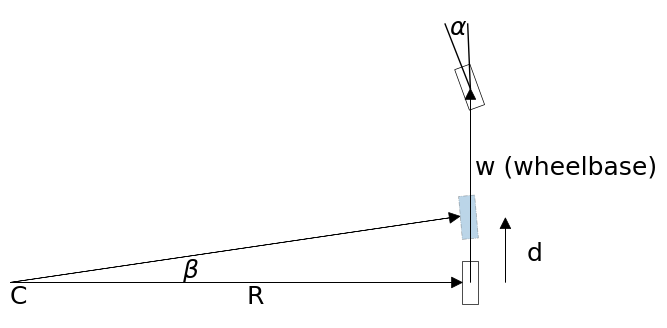

In [10]:
ekf_internal.plot_bicycle()

In the **Unscented Kalman Filter** chapter we derived these equations:

在 **Unscented Kalman Filter** 章节中，我们推导出了这些方程：

$$\begin{aligned} 
\beta &= \frac d w \tan(\alpha) \\
x &= x - R\sin(\theta) + R\sin(\theta + \beta) \\
y &= y + R\cos(\theta) - R\cos(\theta + \beta) \\
\theta &= \theta + \beta
\end{aligned}
$$

where $\theta$ is the robot's heading.

其中 $\theta$ 是机器人的航向。

You do not need to understand this model in detail if you are not interested in steering models. The important thing to recognize is that our motion model is nonlinear, and we will need to deal with that with our Kalman filter.

如果你对转向模型不感兴趣，就不必细究它。要紧的一点是：我们的运动模型是非线性的，需要用卡尔曼滤波器来处理。


### Design the State Variables
### 设计状态变量

For our filter we will maintain the position $x,y$ and orientation $\theta$ of the robot:

对于我们的滤波器，我们将保持机器人的位置 $x,y$ 和方向 $\theta$：

$$\mathbf x = \begin{bmatrix}x \\ y \\ \theta\end{bmatrix}$$

Our control input $\mathbf u$ is the velocity $v$ and steering angle $\alpha$:

我们的控制输入 $\mathbf u$ 是速度 $v$ 和转向角 $\alpha$：

$$\mathbf u = \begin{bmatrix}v \\ \alpha\end{bmatrix}$$


### Design the System Model
### 设计系统模型

We model our system as a nonlinear motion model plus noise.

我们将系统建模为非线性运动模型加上噪声。

$$\bar x = f(x, u) + \mathcal{N}(0, Q)$$

Using the motion model for a robot that we created above, we can expand this to

使用我们在上面创建的机器人的运动模型，我们可以将其扩展为

$$\bar{\begin{bmatrix}x\\y\\\theta\end{bmatrix}} = \begin{bmatrix}x\\y\\\theta\end{bmatrix} + 
\begin{bmatrix}- R\sin(\theta) + R\sin(\theta + \beta) \\
R\cos(\theta) - R\cos(\theta + \beta) \\
\beta\end{bmatrix}$$

We find The $\mathbf F$ by taking the Jacobian of $f(x,u)$.

我们通过取 $f(x,u)$ 的雅可比行列式来找到 $\mathbf F$。

$$\mathbf F = \frac{\partial f(x, u)}{\partial x} =\begin{bmatrix}
\frac{\partial f_1}{\partial x} & 
\frac{\partial f_1}{\partial y} &
\frac{\partial f_1}{\partial \theta}\\
\frac{\partial f_2}{\partial x} & 
\frac{\partial f_2}{\partial y} &
\frac{\partial f_2}{\partial \theta} \\
\frac{\partial f_3}{\partial x} & 
\frac{\partial f_3}{\partial y} &
\frac{\partial f_3}{\partial \theta}
\end{bmatrix}
$$

When we calculate these we get

当我们计算这些时，我们得到

$$\mathbf F = \begin{bmatrix}
1 & 0 & -R\cos(\theta) + R\cos(\theta+\beta) \\
0 & 1 & -R\sin(\theta) + R\sin(\theta+\beta) \\
0 & 0 & 1
\end{bmatrix}$$

We can double check our work with SymPy.

我们可以用 SymPy 仔细检查我们的工作。


In [11]:
import sympy
from sympy.abc import alpha, x, y, v, w, R, theta
from sympy import symbols, Matrix
sympy.init_printing(use_latex="mathjax", fontsize='16pt')
time = symbols('t')
d = v*time
beta = (d/w)*sympy.tan(alpha)
r = w/sympy.tan(alpha)

fxu = Matrix([[x-r*sympy.sin(theta) + r*sympy.sin(theta+beta)],
              [y+r*sympy.cos(theta)- r*sympy.cos(theta+beta)],
              [theta+beta]])
F = fxu.jacobian(Matrix([x, y, theta]))
F

⎡                        ⎛t⋅v⋅tan(α)    ⎞⎤
⎢                   w⋅cos⎜────────── + θ⎟⎥
⎢        w⋅cos(θ)        ⎝    w         ⎠⎥
⎢1  0  - ──────── + ─────────────────────⎥
⎢         tan(α)           tan(α)        ⎥
⎢                                        ⎥
⎢                        ⎛t⋅v⋅tan(α)    ⎞⎥
⎢                   w⋅sin⎜────────── + θ⎟⎥
⎢        w⋅sin(θ)        ⎝    w         ⎠⎥
⎢0  1  - ──────── + ─────────────────────⎥
⎢         tan(α)           tan(α)        ⎥
⎢                                        ⎥
⎣0  0                  1                 ⎦

That looks a bit complicated. We can use SymPy to substitute terms:

那看起来有点复杂。我们可以使用 SymPy 来替换术语：


In [12]:
# reduce common expressions
B, R = symbols('beta, R')
F = F.subs((d/w)*sympy.tan(alpha), B)
F.subs(w/sympy.tan(alpha), R)

⎡1  0  -R⋅cos(θ) + R⋅cos(β + θ)⎤
⎢                              ⎥
⎢0  1  -R⋅sin(θ) + R⋅sin(β + θ)⎥
⎢                              ⎥
⎣0  0             1            ⎦

This form  verifies that the computation of the Jacobian is correct.

这个形式验证了雅可比矩阵的计算是正确的。

Now we can turn our attention to the noise. Here, the noise is in our control input, so it is in *control space*. In other words, we command a specific velocity and steering angle, but we need to convert that into errors in $x, y, \theta$. In a real system this might vary depending on velocity, so it will need to be recomputed for every prediction. I will choose this as the noise model; for a real robot you will need to choose a model that accurately depicts the error in your system.

接下来看噪声。这里噪声出现在控制输入中，因此它位于*控制空间*。换句话说，我们下达的是特定的速度和转向角指令，但需要把它换算成 $x、y、\theta$ 上的误差。在实际系统里，这个换算可能随速度而变，因此每次预测都要重新计算。我这里就选用下面这个噪声模型；换成真实机器人，你得挑一个能准确描述系统误差的模型。

$$\mathbf{M} = \begin{bmatrix}\sigma_{vel}^2 & 0 \\ 0 & \sigma_\alpha^2\end{bmatrix}$$

If this was a linear problem we would convert from control space to state space using the by now familiar $\mathbf{FMF}^\mathsf T$ form. Since our motion model is nonlinear we do not try to find a closed form solution to this, but instead linearize it with a Jacobian which we will name $\mathbf{V}$.

如果这是个线性问题，我们会用已经很熟悉的 $\mathbf{FMF}^\mathsf T$ 形式从控制空间换算到状态空间。但我们的运动模型是非线性的，所以不去求闭式解，而是用一个我们将命名为 $\mathbf{V}$ 的雅可比矩阵来做线性化。

$$\mathbf{V} = \frac{\partial f(x, u)}{\partial u} \begin{bmatrix}
\frac{\partial f_1}{\partial v} & \frac{\partial f_1}{\partial \alpha} \\
\frac{\partial f_2}{\partial v} & \frac{\partial f_2}{\partial \alpha} \\
\frac{\partial f_3}{\partial v} & \frac{\partial f_3}{\partial \alpha}
\end{bmatrix}$$

These partial derivatives become very difficult to work with. Let's compute them with SymPy.

这些偏导数变得非常繁琐，我们用 SymPy 来算。


In [13]:
V = fxu.jacobian(Matrix([v, alpha]))
V = V.subs(sympy.tan(alpha)/w, 1/R) 
V = V.subs(time*v/R, B)
V = V.subs(time*v, 'd')
V

⎡                ⎛   2       ⎞                ⎛     2       ⎞            ⎛     ↪
⎢              d⋅⎝tan (α) + 1⎠⋅cos(β + θ)   w⋅⎝- tan (α) - 1⎠⋅sin(θ)   w⋅⎝- ta ↪
⎢t⋅cos(β + θ)  ────────────────────────── - ──────────────────────── + ─────── ↪
⎢                        tan(α)                        2                       ↪
⎢                                                   tan (α)                    ↪
⎢                                                                              ↪
⎢                ⎛   2       ⎞                ⎛     2       ⎞            ⎛     ↪
⎢              d⋅⎝tan (α) + 1⎠⋅sin(β + θ)   w⋅⎝- tan (α) - 1⎠⋅cos(θ)   w⋅⎝- ta ↪
⎢t⋅sin(β + θ)  ────────────────────────── + ──────────────────────── - ─────── ↪
⎢                        tan(α)                        2                       ↪
⎢                                                   tan (α)                    ↪
⎢                                                                              ↪
⎢                           

This should give you an appreciation of how quickly the EKF become mathematically intractable.

这应该能让你体会到，EKF 的数学推导很快会变得多么难以驾驭。

This gives us the final form of our prediction equations:

这为我们提供了预测方程的最终形式：

$$\begin{aligned}
\mathbf{\bar x} &= \mathbf x + 
\begin{bmatrix}- R\sin(\theta) + R\sin(\theta + \beta) \\
R\cos(\theta) - R\cos(\theta + \beta) \\
\beta\end{bmatrix}\\
\mathbf{\bar P} &=\mathbf{FPF}^{\mathsf T} + \mathbf{VMV}^{\mathsf T}
\end{aligned}$$

This form of linearization is not the only way to predict $\mathbf x$. For example, we could use a numerical integration technique such as *Runge Kutta* to compute the movement
of the robot. This will be required if the time step is relatively large. Things are not as cut and dried with the EKF as for the Kalman filter. For a real problem you have to carefully model your system with differential equations and then determine the most appropriate way to solve that system. The correct approach depends on the accuracy you require, how nonlinear the equations are, your processor budget, and numerical stability concerns.

这种线性化形式并不是预测 $\mathbf x$ 的唯一办法。例如我们也可以用*龙格-库塔*等数值积分方法来计算机器人的运动。时间步长较大时，这是必需的。用 EKF 不像用卡尔曼滤波器那样有固定套路：面对实际问题，你必须用微分方程仔细地为系统建模，然后决定最合适的求解方式。究竟选哪种，取决于你需要的精度、方程的非线性程度、处理器的运算预算，以及数值稳定性。


### Design the Measurement Model
### 设计测量模型

The robot's sensor provides a noisy bearing and range measurement to multiple known locations in the landscape. The measurement model must convert the state $\begin{bmatrix}x & y&\theta\end{bmatrix}^\mathsf T$ into a range and bearing to the landmark. If $\mathbf p$ 
is the position of a landmark, the range $r$ is

机器人的传感器为景观中的多个已知位置提供嘈杂的方位和距离测量。测量模型必须将状态 $\begin{bmatrix}x & y&\theta\end{bmatrix}^\mathsf T$ 转换为一个范围并指向地标。如果 $\mathbf p$
是地标的位置，范围 $r$ 是

$$r = \sqrt{(p_x - x)^2 + (p_y - y)^2}$$

The sensor provides bearing relative to the orientation of the robot, so we must subtract the robot's orientation from the bearing to get the sensor reading, like so:

传感器提供相对于机器人方向的方位，因此我们必须从方位中减去机器人的方位以获得传感器读数，如下所示：

$$\phi = \arctan(\frac{p_y - y}{p_x - x}) - \theta$$

Thus our measurement model $h$ is

因此我们的测量模型 $h$ 是

$$\begin{aligned}
\mathbf z& = h(\bar{\mathbf x}, \mathbf p) &+ \mathcal{N}(0, R)\\
&= \begin{bmatrix}
\sqrt{(p_x - x)^2 + (p_y - y)^2} \\
\arctan(\frac{p_y - y}{p_x - x}) - \theta 
\end{bmatrix} &+ \mathcal{N}(0, R)
\end{aligned}$$

This is clearly nonlinear, so we need linearize $h$  at $\mathbf x$ by taking its Jacobian. We compute that with SymPy below.

这显然是非线性的，因此需要求 $h$ 在 $\mathbf x$ 处的雅可比矩阵来做线性化。下面用 SymPy 来算。


In [14]:
px, py = symbols('p_x, p_y')
z = Matrix([[sympy.sqrt((px-x)**2 + (py-y)**2)],
            [sympy.atan2(py-y, px-x) - theta]])
z.jacobian(Matrix([x, y, theta]))

⎡          -pₓ + x                     -p_y + y              ⎤
⎢───────────────────────────  ───────────────────────────  0 ⎥
⎢   ________________________     ________________________    ⎥
⎢  ╱         2            2     ╱         2            2     ⎥
⎢╲╱  (pₓ - x)  + (p_y - y)    ╲╱  (pₓ - x)  + (p_y - y)      ⎥
⎢                                                            ⎥
⎢       -(-p_y + y)                   -(pₓ - x)              ⎥
⎢  ──────────────────────       ──────────────────────     -1⎥
⎢          2            2               2            2       ⎥
⎣  (pₓ - x)  + (p_y - y)        (pₓ - x)  + (p_y - y)        ⎦

Now we need to write that as a Python function. For example we might write:

现在我们需要把它写成一个 Python 函数。例如我们可能会写：


In [15]:
from math import sqrt

def H_of(x, landmark_pos):
    """ compute Jacobian of H matrix where h(x) computes 
    the range and bearing to a landmark for state x """

    px = landmark_pos[0]
    py = landmark_pos[1]
    hyp = (px - x[0, 0])**2 + (py - x[1, 0])**2
    dist = sqrt(hyp)

    H = array(
        [[-(px - x[0, 0]) / dist, -(py - x[1, 0]) / dist, 0],
         [ (py - x[1, 0]) / hyp,  -(px - x[0, 0]) / hyp, -1]])
    return H

We also need to define a function that converts the system state into a measurement.

我们还需要定义一个把系统状态转换为测量值的函数。


In [16]:
from math import atan2

def Hx(x, landmark_pos):
    """ takes a state variable and returns the measurement
    that would correspond to that state.
    """
    px = landmark_pos[0]
    py = landmark_pos[1]
    dist = sqrt((px - x[0, 0])**2 + (py - x[1, 0])**2)

    Hx = array([[dist],
                [atan2(py - x[1, 0], px - x[0, 0]) - x[2, 0]]])
    return Hx

### Design Measurement Noise
### 设计测量噪声

It is reasonable to assume that the noise of the range and bearing measurements are independent, hence

可以合理地假设距离和方位测量的噪声是独立的，因此

$$\mathbf R=\begin{bmatrix}\sigma_{range}^2 & 0 \\ 0 & \sigma_{bearing}^2\end{bmatrix}$$


### Implementation
### 实现

We will use `FilterPy`'s `ExtendedKalmanFilter` class to implement the filter. Its `predict()` method uses the standard linear equations for the process model. Ours is nonlinear, so we will have to override `predict()` with our own implementation.  I'll want to also use this class to simulate the robot, so I'll add a method `move()` that computes the position of the robot which both `predict()` and my simulation can call.

我们将使用 `FilterPy` 的 `ExtendedKalmanFilter` 类来实现滤波器。它的“predict()”方法使用过程模型的标准线性方程。我们是非线性的，所以我们必须用我们自己的实现覆盖 `predict()`。我还想使用这个类来模拟机器人，所以我将添加一个方法 `move()` 来计算机器人的位置，`predict()` 和我的模拟都可以调用。

The matrices for the prediction step are quite large. While writing this code I made several errors before I finally got it working. I only found my errors by using SymPy's `evalf` function. `evalf` evaluates a SymPy `Matrix` with specific values for the variables. I decided to demonstrate this technique to you, and used `evalf` in the Kalman filter code. You'll need to understand a couple of points.

预测步骤的矩阵非常大。写这段代码时，我犯了好几个错误才最终跑通，全靠 SymPy 的 `evalf` 函数才发现问题。`evalf` 用变量的具体取值来求 SymPy `Matrix` 的值。我决定在卡尔曼滤波器的代码中演示这个技巧，有几点你需要知道。

First, `evalf` uses a dictionary to specify the values. For example, if your matrix contains an `x` and `y`, you can write

首先，`evalf` 使用字典来指定值。例如，如果你的矩阵包含一个 `x` 和 `y`，你可以写

```python
    M.evalf(subs={x:3, y:17})
```

to evaluate the matrix for `x=3` and `y=17`.

即可求出矩阵在 $x=3$、$y=17$ 处的值。

Second, `evalf` returns a `sympy.Matrix` object. Use `numpy.array(M).astype(float)` to convert it to a NumPy array. `numpy.array(M)` creates an array of  type `object`, which is not what you want.

其次，`evalf` 返回的是 `sympy.Matrix` 对象，要用 `numpy.array(M).astype(float)` 转成 NumPy 数组。若只写 `numpy.array(M)`，得到的数组 dtype 是 `object`，那可不是你想要的。

Here is the code for the EKF:

这是EKF的代码：


In [17]:
from filterpy.kalman import ExtendedKalmanFilter as EKF
from numpy import array, sqrt
class RobotEKF(EKF):
    def __init__(self, dt, wheelbase, std_vel, std_steer):
        EKF.__init__(self, 3, 2, 2)
        self.dt = dt
        self.wheelbase = wheelbase
        self.std_vel = std_vel
        self.std_steer = std_steer

        a, x, y, v, w, theta, time = symbols(
            'a, x, y, v, w, theta, t')
        d = v*time
        beta = (d/w)*sympy.tan(a)
        r = w/sympy.tan(a)
    
        self.fxu = Matrix(
            [[x-r*sympy.sin(theta)+r*sympy.sin(theta+beta)],
             [y+r*sympy.cos(theta)-r*sympy.cos(theta+beta)],
             [theta+beta]])

        self.F_j = self.fxu.jacobian(Matrix([x, y, theta]))
        self.V_j = self.fxu.jacobian(Matrix([v, a]))

        # save dictionary and it's variables for later use
        self.subs = {x: 0, y: 0, v:0, a:0, 
                     time:dt, w:wheelbase, theta:0}
        self.x_x, self.x_y, = x, y 
        self.v, self.a, self.theta = v, a, theta

    def predict(self, u):
        self.x = self.move(self.x, u, self.dt)

        self.subs[self.theta] = self.x[2, 0]
        self.subs[self.v] = u[0]
        self.subs[self.a] = u[1]

        F = array(self.F_j.evalf(subs=self.subs)).astype(float)
        V = array(self.V_j.evalf(subs=self.subs)).astype(float)

        # covariance of motion noise in control space
        M = array([[self.std_vel*u[0]**2, 0], 
                   [0, self.std_steer**2]])

        self.P = F @ self.P @ F.T + V @ M @ V.T

    def move(self, x, u, dt):
        hdg = x[2, 0]
        vel = u[0]
        steering_angle = u[1]
        dist = vel * dt

        if abs(steering_angle) > 0.001: # is robot turning?
            beta = (dist / self.wheelbase) * tan(steering_angle)
            r = self.wheelbase / tan(steering_angle) # radius

            dx = np.array([[-r*sin(hdg) + r*sin(hdg + beta)], 
                           [r*cos(hdg) - r*cos(hdg + beta)], 
                           [beta]])
        else: # moving in straight line
            dx = np.array([[dist*cos(hdg)], 
                           [dist*sin(hdg)], 
                           [0]])
        return x + dx

Now we have another issue to handle. The residual is notionally computed as $y = z - h(x)$ but this will not work because our measurement contains an angle in it. Suppose z has a bearing of $1^\circ$ and $h(x)$ has a bearing of $359^\circ$. Naively subtracting them would yield a angular difference of $-358^\circ$, whereas the correct value is $2^\circ$. We have to write code to correctly compute the bearing residual.

接下来还有另一个问题。残差按定义是 $y = z - h(x)$，但这里不能直接相减，因为测量中包含角度。假设 $z$ 的方位角是 $1^\circ$，$h(x)$ 给出的方位角是 $359^\circ$，直接相减得到 $-358^\circ$，而正确的角度差应是 $2^\circ$。我们必须编写代码来正确计算方位残差。


In [18]:
def residual(a, b):
    """ compute residual (a-b) between measurements containing 
    [range, bearing]. Bearing is normalized to [-pi, pi)"""
    y = a - b
    y[1] = y[1] % (2 * np.pi)    # force in range [0, 2 pi)
    if y[1] > np.pi:             # move to [-pi, pi)
        y[1] -= 2 * np.pi
    return y

The rest of the code runs the simulation and plots the results, and shouldn't need too much comment by now. I create a variable `landmarks` that contains the landmark coordinates. I update the simulated robot position 10 times a second, but run the EKF only once per second. This is for two reasons. First, we are not using Runge Kutta to integrate the differental equations of motion, so a narrow time step allows our simulation to be more accurate. Second, it is fairly normal in embedded systems to have limited processing speed. This forces you to run your Kalman filter only as frequently as absolutely needed.

剩下的代码负责运行模拟并绘制结果，已无需太多注释。我创建了一个变量 `landmarks` 存放地标坐标。模拟中机器人位置每秒更新 10 次，而 EKF 每秒只运行一次，原因有二。第一，我们没有用龙格-库塔法对运动微分方程做积分，所以较小的时间步长能让模拟更准确。第二，嵌入式系统处理能力有限是常态，这迫使你只在确有必要时才运行卡尔曼滤波器。


In [19]:
from filterpy.stats import plot_covariance_ellipse
from math import sqrt, tan, cos, sin, atan2
import matplotlib.pyplot as plt

dt = 1.0

def z_landmark(lmark, sim_pos, std_rng, std_brg):
    x, y = sim_pos[0, 0], sim_pos[1, 0]
    d = np.sqrt((lmark[0] - x)**2 + (lmark[1] - y)**2)  
    a = atan2(lmark[1] - y, lmark[0] - x) - sim_pos[2, 0]
    z = np.array([[d + randn()*std_rng],
                  [a + randn()*std_brg]])
    return z

def ekf_update(ekf, z, landmark):
    ekf.update(z, HJacobian=H_of, Hx=Hx, 
               residual=residual,
               args=(landmark), hx_args=(landmark))
    
                
def run_localization(landmarks, std_vel, std_steer, 
                     std_range, std_bearing,
                     step=10, ellipse_step=20, ylim=None):
    ekf = RobotEKF(dt, wheelbase=0.5, std_vel=std_vel, 
                   std_steer=std_steer)
    ekf.x = array([[2, 6, .3]]).T # x, y, steer angle
    ekf.P = np.diag([.1, .1, .1])
    ekf.R = np.diag([std_range**2, std_bearing**2])

    sim_pos = ekf.x.copy() # simulated position
    # steering command (vel, steering angle radians)
    u = array([1.1, .01]) 

    plt.figure()
    plt.scatter(landmarks[:, 0], landmarks[:, 1],
                marker='s', s=60)
    
    track = []
    for i in range(200):
        sim_pos = ekf.move(sim_pos, u, dt/10.) # simulate robot
        track.append(sim_pos)

        if i % step == 0:
            ekf.predict(u=u)

            if i % ellipse_step == 0:
                plot_covariance_ellipse(
                    (ekf.x[0,0], ekf.x[1,0]), ekf.P[0:2, 0:2], 
                     std=6, facecolor='k', alpha=0.3)

            x, y = sim_pos[0, 0], sim_pos[1, 0]
            for lmark in landmarks:
                z = z_landmark(lmark, sim_pos,
                               std_range, std_bearing)
                ekf_update(ekf, z, lmark)

            if i % ellipse_step == 0:
                plot_covariance_ellipse(
                    (ekf.x[0,0], ekf.x[1,0]), ekf.P[0:2, 0:2],
                    std=6, facecolor='g', alpha=0.8)
    track = np.array(track)
    plt.plot(track[:, 0], track[:,1], color='k', lw=2)
    plt.axis('equal')
    plt.title("EKF Robot localization")
    if ylim is not None: plt.ylim(*ylim)
    plt.show()
    return ekf

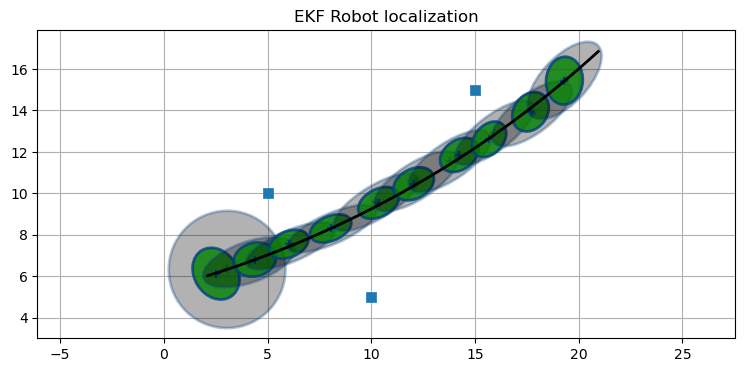

Final P: [0.024 0.042 0.002]


In [20]:
landmarks = array([[5, 10], [10, 5], [15, 15]])

ekf = run_localization(
    landmarks, std_vel=0.1, std_steer=np.radians(1),
    std_range=0.3, std_bearing=0.1)
print('Final P:', ekf.P.diagonal())

I have plotted the landmarks as solid squares. The path of the robot is drawn with a black line. The covariance ellipses for the predict step are light gray, and the covariances of the update are shown in green. To make them visible at this scale I have set the ellipse boundary at 6$\sigma$.

地标画成实心方块，机器人的路径画成黑线。预测步骤的协方差椭圆用浅灰色，更新后的协方差用绿色。为了让它们在这个比例下看得见，我把椭圆边界设成了 6$\sigma$。

We can see that there is a lot of uncertainty added by our motion model, and that most of the error in in the direction of motion. We determine that from the shape of the blue ellipses. After a few steps we can see that the filter incorporates the landmark measurements and the errors improve.

可以看到，运动模型引入了相当多的不确定性，而且误差大多集中在运动方向上，这一点从蓝色椭圆的形状就能看出。经过若干步骤后，滤波器把地标测量融合进来，误差随之减小。

I used the same initial conditions and landmark locations in the UKF chapter. The UKF achieves much better accuracy in terms of the error ellipse. Both perform roughly as well as far as their estimate for $\mathbf x$ is concerned.

我在 UKF 一章里用的是同一组初始条件和地标位置。就误差椭圆而言，UKF 的精度更好；但就它们对 $\mathbf x$ 的估计来说，两者表现差不多。

Now let's add another landmark.

现在让我们添加另一个地标。


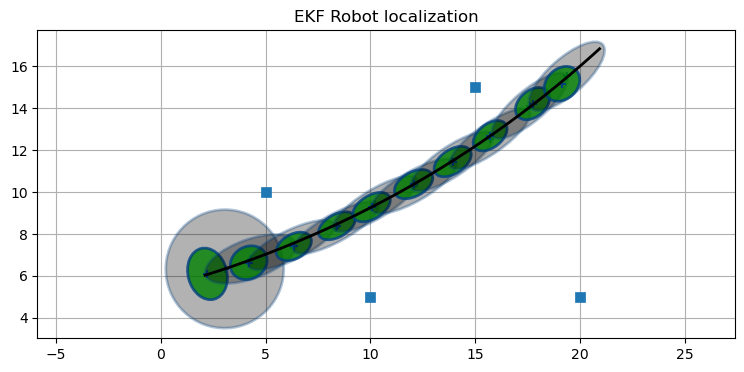

Final P: [0.021 0.02  0.002]


In [21]:
landmarks = array([[5, 10], [10, 5], [15, 15], [20, 5]])

ekf = run_localization(
    landmarks, std_vel=0.1, std_steer=np.radians(1),
    std_range=0.3, std_bearing=0.1)
plt.show()
print('Final P:', ekf.P.diagonal())

The uncertainly in the estimates near the end of the track are smaller. We can see the effect that multiple landmarks have on our uncertainty by only using the first two landmarks.

接近轨迹末端时，估计的不确定性较小。只用前两个地标，就能看出多个地标对不确定性的影响。


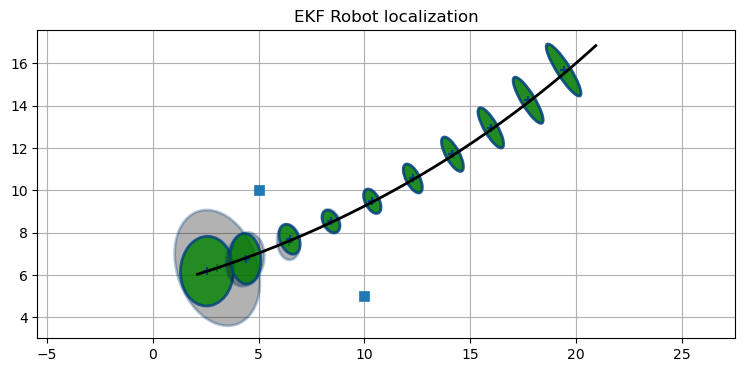

Final P: [0.022 0.046 0.   ]


In [22]:
ekf = run_localization(
    landmarks[0:2], std_vel=1.e-10, std_steer=1.e-10,
    std_range=1.4, std_bearing=.05)
print('Final P:', ekf.P.diagonal())

The estimate quickly diverges from the robot's path after passing the landmarks. The covariance also grows quickly. Let's see what happens with only one landmark:

越过地标之后，估计值会迅速偏离机器人的真实路径，协方差也快速增长。下面看看只有一个地标的情形：


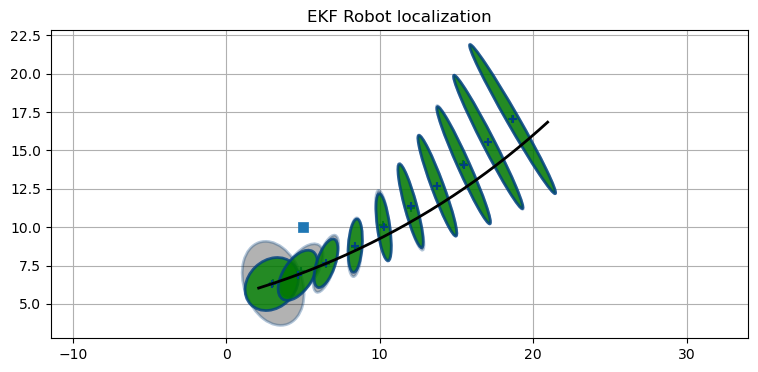

Final P: [0.263 0.722 0.003]


In [23]:
ekf = run_localization(
    landmarks[0:1], std_vel=1.e-10, std_steer=1.e-10,
    std_range=1.4, std_bearing=.05)
print('Final P:', ekf.P.diagonal())

As you probably suspected, one landmark produces a very bad result. Conversely, a large number of landmarks allows us to make very accurate estimates.

正如你可能怀疑的那样，一个地标会产生非常糟糕的结果。相反，大量的地标使我们能够做出非常准确的估计。


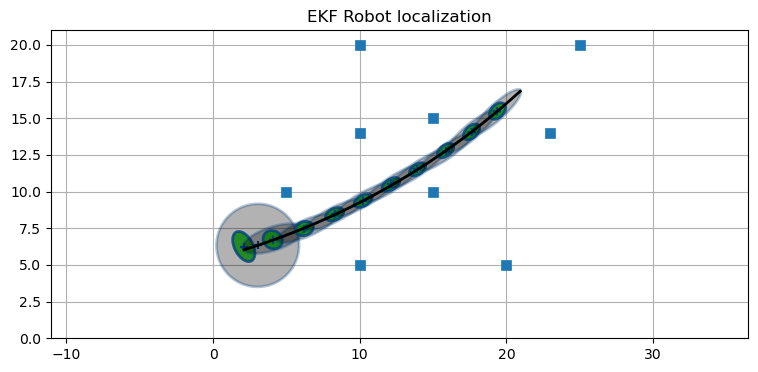

Final P: [0.009 0.009 0.001]


In [24]:
landmarks = array([[5, 10], [10,  5], [15, 15], [20,  5], [15, 10], 
                   [10,14], [23, 14], [25, 20], [10, 20]])

ekf = run_localization(
    landmarks, std_vel=0.1, std_steer=np.radians(1),
    std_range=0.3, std_bearing=0.1, ylim=(0, 21))
print('Final P:', ekf.P.diagonal())

### Discussion
### 讨论

I said that this was a real problem, and in some ways it is. I've seen alternative presentations that used robot motion models that led to simpler Jacobians. On the other hand, my model of the movement is also simplistic in several ways. First, it uses a bicycle model. A real car has two sets of tires, and each travels on a different radius. The wheels do not grip the surface perfectly. I also assumed that the robot responds instantaneously to the control input. Sebastian Thrun writes in *Probabilistic Robots* that this simplified model is justified because the filters perform well when used to track real vehicles. The lesson here is that while you have to have a reasonably accurate nonlinear model, it does not need to be perfect to operate well. As a designer you will need to balance the fidelity of your model with the difficulty of the math and the CPU time required to perform the linear algebra.

我说过这是个真正的难题，某些方面的确如此。我也见过一些用机器人运动模型做的替代演示，它们能导出更简单的雅可比矩阵。反过来看，我的运动模型本身也有几处简化：它用的是自行车模型，而真实汽车有两组轮胎、转弯半径各不相同；轮子也无法完全抓牢地面。我还假设机器人会立即响应控制输入。Sebastian Thrun 在 *Probabilistic Robots* 中写道，这种简化模型是站得住脚的，因为滤波器用于跟踪真实车辆时表现良好。这里的经验是：非线性模型必须足够准确，但无须完美就能工作得不错。作为设计者，你需要在模型保真度、数学难度和做线性代数所需的 CPU 时间之间权衡。

Another way in which this problem was simplistic is that we assumed that we knew the correspondance between the landmarks and measurements. But suppose we are using radar - how would we know that a specific signal return corresponded to a specific building in the local scene? This question hints at SLAM algorithms - simultaneous localization and mapping. SLAM is not the point of this book, so I will not elaborate on this topic.

这个问题的另一处简化，是我们假定已知地标与测量值之间的对应关系。可如果用的是雷达，我们怎么知道某次信号回波对应场景中的哪一栋建筑呢？这就是 SLAM（同时定位与建图）算法要解决的问题。SLAM 不是本书重点，所以这里不再展开。


## UKF vs EKF
## UKF 与 EKF 的比较

In the last chapter I used the UKF to solve this problem. The difference in implementation should be very clear. Computing the Jacobians for the state and measurement models was not trivial despite a rudimentary motion model. A different problem could result in a Jacobian which is difficult or impossible to derive analytically. In contrast, the UKF only requires you to provide a function that computes the system motion model and another for the measurement model.

上一章我用 UKF 解决了同样的问题。两者在实现上的差别应该很明显：即便运动模型很简单，求状态模型和测量模型的雅可比矩阵也绝非易事；换一个问题，雅可比矩阵可能就很难、甚至无法解析推导。相比之下，UKF 只需要你提供一个计算系统运动模型的函数，以及一个计算测量模型的函数。

There are many cases where the Jacobian cannot be found analytically. The details are beyond the scope of this book, but you will have to use numerical methods to compute the Jacobian. That undertaking is not trivial, and you will spend a significant portion of a master's degree at a STEM school learning techniques to handle such situations. Even then you'll likely only be able to solve problems related to your field - an aeronautical engineer learns a lot about Navier Stokes equations, but not much about modelling chemical reaction rates.

很多情况下无法解析地求出雅可比矩阵。细节超出本书范围，但你只能改用数值方法计算。这并不轻松，在理工科硕士阶段你会花大量时间学习应对这类情形的技术。即便如此，你大概率也只能解决本领域内的问题，航空工程师对纳维-斯托克斯方程懂得很多，对化学反应速率的建模却知之甚少。

So, UKFs are easy. Are they accurate? In practice they often perform better than the EKF. You can find plenty of research papers that prove that the UKF outperforms the EKF in various problem domains. It's not hard to understand why this would be true. The EKF works by linearizing the system model and measurement model at a single point, and the UKF uses $2n+1$ points.

可见 UKF 用起来容易。那它准确吗？在实践中，它的表现通常优于 EKF。有大量研究论文表明，UKF 在各类问题上都胜过 EKF。原因不难理解：EKF 只在单个点上对系统模型和测量模型做线性化，而 UKF 用了 $2n+1$ 个点。

Let's look at a specific example. Take $f(x) = x^3$ and pass a Gaussian distribution through it. I will compute an accurate answer using a monte carlo simulation. I generate 50,000 points randomly distributed according to the Gaussian, pass each through $f(x)$, then compute the mean and variance of the result.

来看一个具体的例子。取 $f(x) = x^3$，让一个高斯分布通过它。我用蒙特卡洛模拟来算出准确答案：按高斯分布随机生成 50,000 个点，让每个点通过 $f(x)$，再计算结果的均值和方差。

The EKF linearizes the function by taking the derivative to find the slope at the evaluation point $x$. This slope becomes the linear function that we use to transform the Gaussian. Here is a plot of that.

EKF 通过求导数来找到评估点 $x$ 处的斜率来线性化函数。这个斜率成为我们用来变换高斯的线性函数。图示如下。


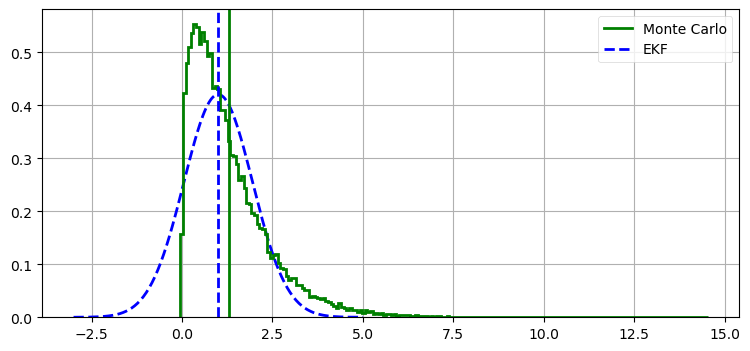

actual mean=1.30, std=1.12
EKF    mean=1.00, std=0.95


In [25]:
import kf_book.nonlinear_plots as nonlinear_plots
nonlinear_plots.plot_ekf_vs_mc()

The EKF computation is rather inaccurate. In contrast, here is the performance of the UKF:

EKF 计算相当不准确。相比之下，这是 UKF 的表现：


In [27]:
nonlinear_plots.plot_ukf_vs_mc(alpha=0.001, beta=3., kappa=1.)

TypeError: only 0-dimensional arrays can be converted to Python scalars

Here we can see that the computation of the UKF's mean is accurate to 2 decimal places. The standard deviation is slightly off, but you can also fine tune how the UKF computes the distribution by using the $\alpha$, $\beta$, and $\gamma$ parameters for generating the sigma points. Here I used $\alpha=0.001$, $\beta=3$, and $\gamma=1$. Feel free to modify them to see the result. You should be able to get better results than I did. However, avoid over-tuning the UKF for a specific test. It may perform better for your test case, but worse in general.

可以看到，UKF 算出的均值精确到小数点后两位；标准差略有偏差，但你也可以通过 $\alpha$、$\beta$ 和 $\gamma$ 参数来微调 UKF 生成 sigma 点、计算分布的方式。这里我取 $\alpha=0.001$、$\beta=3$、$\gamma=1$，不妨改动看看结果，你应该能做得比我更好。但不要为某个特定测试把 UKF 调得过头：它可能在该测试上表现更好，整体表现却会更差。
